# 5. Fiscal space and sovereign spreads: how much debt can Italy carry?

**Questions.** How do euro-area governments adjust their primary balance when debt rises, and does the response weaken
at high debt ("fiscal fatigue")? Given Italy's historical behaviour and plausible interest rates and growth, is there a debt
level beyond which the debt ratio would keep rising? How far is Italy from it? How much do markets charge for higher debt, and
how much of the BTP-Bund spread do fundamentals explain?

**Method.**

1. *Panel fiscal reaction function* (Ghosh, Kim, Mendoza, Ostry and Qureshi, 2013) on 13 advanced EU economies,
   1996-2025: $pb_{it} = \mu_i + \lambda_t + \beta_1 d_{i,t-1} + \beta_2 d_{i,t-1}^2 + \beta_3 d_{i,t-1}^3 + \gamma\, gap_{it} + \varepsilon_{it}$,
   fixed effects, year effects, and Driscoll-Kraay standard errors (robust to serial and cross-country correlation).
2. *Debt limit*: the largest debt ratio at which the reaction function still reaches the debt-stabilising primary balance
   $\frac{r - g}{1 + g}\, d$; *fiscal space* is the limit minus current debt. Parameter uncertainty is handled by drawing the
   coefficients from their estimated distribution.
3. *Spreads*: 10-year spreads over the Bund in nine euro-area countries, 1999-2025, regressed on lagged debt, the lagged
   primary balance and growth, with a debt slope that can change after 2008. The estimated slope feeds back into the interest
   rate of the debt limit.

**Data.** Eurostat `gov_10dd_edpt1` (general government debt, net lending and interest, EDP notification), `nama_10_gdp`
(real growth, output gap by an HP filter with $\lambda = 100$) and `irt_lt_mcby_a` (10-year yields, Maastricht criterion).

**Reading guide.** The panel estimates describe *average historical behaviour*; the debt limit is a model construct that is
very sensitive to specification, as section 4 shows. Facts from the data, estimates and judgements are kept separate.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "public_debt").is_dir())
try:
    import public_debt
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "public_debt"))
    import public_debt
from public_debt import accounting, data, dsa, fiscal, growth, synthetic
from public_debt.var import fit_var1

core = public_debt.require_cpp()

DATA_MODE = os.environ.get("PUBLIC_DEBT_DATA_MODE", "official")   # "official" (Eurostat, IMF) or "synthetic" (offline)
OFFICIAL = DATA_MODE == "official"
OUTPUT_DIR = ROOT / "outputs" / "fiscal_space"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
from public_debt.figstyle import (MUTED, NEGATIVE, NOTEBOOK, SERIES, figure_headline, headline, label_ends,
                                  notebook_style, ordinal_colors)
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
print(f"public_debt {public_debt.__version__} | data mode: {DATA_MODE}")
if not OFFICIAL:
    print("WARNING: synthetic data. Tables and charts are placeholders, not statistics about Italy.")

from public_debt import fiscal_space as fs

GEOS = fs.ADVANCED_EU               # 13 advanced EU economies (Greece is "EL" in Eurostat codes)
NO_GREECE = [g for g in GEOS if g != "EL"]
SPREAD_GEOS = fs.EURO_AREA_SPREAD   # euro-area members with a spread over the Bund (Germany is the benchmark)
BREAK_YEAR = 2009                   # first year of the post-crisis regime for spreads
DK_LAGS = 2                         # Newey-West lags of the Driscoll-Kraay standard errors (annual data)
# Long-run assumptions for the debt limit, consistent with notebook 4: real growth 0.8%, GDP deflator 2%.
G_NOMINAL = (1 + 0.008) * (1 + 0.020) - 1
R_SCENARIOS = {"r - g = 0 (r = 2.8%)": G_NOMINAL, "r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield)": 0.036,
               "r - g = 1.7 pp (r = 4.5%)": 0.045}
N_DRAWS, SEED = 5000, 20250101

public_debt 0.1.0 | data mode: official


## 1. The panel

Debt and primary balances of the 13 countries. The primary balance is net lending plus interest paid.

Source: Eurostat gov_10dd_edpt1, nama_10_gdp, irt_lt_mcby_a
13 countries, 1995-2025, 398 country-years


,debt_1995,debt_2025,mean_primary_balance,mean_real_growth
geo,,,,
EL,100.40,146.10,-0.80,1.20
IT,119.10,137.10,1.20,0.70
FR,57.80,115.60,-1.70,1.60
BE,131.50,107.90,1.60,1.80
ES,61.60,100.70,-1.30,2.10
PT,62.20,89.70,-0.70,1.50
FI,55.20,88.50,1.50,1.90
AT,68.60,81.50,-0.20,1.60
DE,54.90,63.50,0.20,1.20


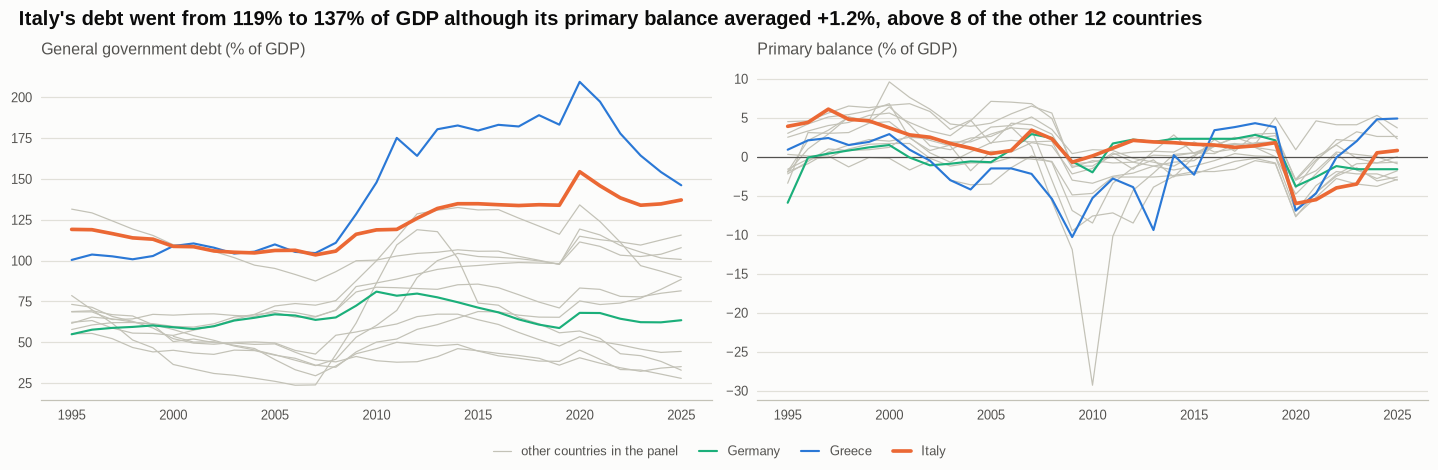

In [2]:
panel = fs.panel_dataset(GEOS, official=OFFICIAL)
print("Source:", panel.attrs.get("source"))
years = panel["year"]
print(f"{panel['geo'].nunique()} countries, {years.min()}-{years.max()}, {panel['debt'].notna().sum()} country-years")
summary = panel.groupby("geo").agg(debt_1995=("debt", "first"), debt_2025=("debt", "last"),
                                   mean_primary_balance=("primary_balance", "mean"),
                                   mean_real_growth=("real_growth", "mean"))
display((100 * summary).sort_values("debt_2025", ascending=False).round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
# Grey context lines for the panel; colour only for the countries the text discusses.
HIGHLIGHT = {"IT": ("Italy", SERIES[1], 2.4), "EL": ("Greece", SERIES[0], 1.4), "DE": ("Germany", SERIES[2], 1.4)}
for geo, g in panel.groupby("geo"):
    name, color, lw = HIGHLIGHT.get(geo, ("other countries in the panel", NOTEBOOK["axis"], 0.8))
    z = 5 if geo in HIGHLIGHT else 1
    label = name if geo in HIGHLIGHT or geo == next(c for c in panel["geo"].unique() if c not in HIGHLIGHT) else None
    axes[0].plot(g["year"], 100 * g["debt"], color=color, lw=lw, zorder=z, label=label)
    axes[1].plot(g["year"], 100 * g["primary_balance"], color=color, lw=lw, zorder=z)
axes[0].set(title="General government debt (% of GDP)")
axes[1].axhline(0, color=NOTEBOOK["ink2"], lw=0.8)
axes[1].set(title="Primary balance (% of GDP)")
s_it = summary.loc["IT"]
beaten = int((summary["mean_primary_balance"].drop("IT") < s_it["mean_primary_balance"]).sum())
link = "although" if s_it["mean_primary_balance"] > 0 and s_it["debt_2025"] > s_it["debt_1995"] else "while"
figure_headline(fig, f"Italy's debt went from {100 * s_it['debt_1995']:.0f}% to {100 * s_it['debt_2025']:.0f}% of GDP {link} "
                     f"its primary balance averaged {100 * s_it['mean_primary_balance']:+.1f}%, above {beaten} of the "
                     f"other {len(summary) - 1} countries")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=4)
fig.savefig(OUTPUT_DIR / "panel.png", dpi=150)

## 2. Panel fiscal reaction functions

Linear and cubic specifications, with and without year effects; the cubic with year effects on the 12 countries without
Greece is the baseline. Greece's high-debt observations (2010-2018) come from EU-IMF adjustment programmes financed by the
official sector, where primary surpluses were a condition of the loans rather than a response of a market-financed
government. Including them also identifies the reaction function beyond 150% of GDP almost entirely from one country. The
full sample is kept as the main robustness check.

In [3]:
specs = {
    "linear, country effects": dict(degree=1, time_effects=False, geos=NO_GREECE),
    "cubic, country effects": dict(degree=3, time_effects=False, geos=NO_GREECE),
    "cubic, country and year effects (baseline)": dict(degree=3, time_effects=True, geos=NO_GREECE),
    "baseline, with Greece": dict(degree=3, time_effects=True, geos=None),
    "baseline, 1996-2019": dict(degree=3, time_effects=True, geos=NO_GREECE, exclude_years=range(2020, 2026)),
    "baseline, errors clustered by country": dict(degree=3, time_effects=True, geos=NO_GREECE, se="cluster"),
}
fits = {k: fs.fiscal_reaction_panel(panel, lags=DK_LAGS, **kw) for k, kw in specs.items()}
rows = {}
for name, r in fits.items():
    row = {f"{c}": f"{r['coef'][c]:.3f} ({r['se'][c]:.3f})" for c in r["coef"].index}
    b = r["coef"]
    if r["degree"] == 3:
        roots = np.sort(np.roots([3 * b["debt_lag^3"], 2 * b["debt_lag^2"], b["debt_lag"]]).real)
        row["response rises between (% of GDP)"] = f"{100 * roots[0]:.0f}-{100 * roots[1]:.0f}"
    row["within R2"], row["observations"] = f"{r['r2_within']:.2f}", r["n"]
    rows[name] = row
table = pd.DataFrame(rows).T.fillna("")
print("Coefficients (standard errors); debt and balances as fractions of GDP")
display(table)
base = fits["cubic, country and year effects (baseline)"]
full = fits["baseline, with Greece"]

Coefficients (standard errors); debt and balances as fractions of GDP


,debt_lag,gap,within R2,observations,debt_lag^2,debt_lag^3,response rises between (% of GDP)
"linear, country effects",0.006 (0.020),0.493 (0.155),0.15,355,,,
"cubic, country effects",-0.057 (0.250),0.489 (0.148),0.15,355,0.077 (0.309),-0.029 (0.118),53-125
"cubic, country and year effects (baseline)",-0.367 (0.187),0.316 (0.131),0.53,355,0.470 (0.225),-0.171 (0.084),56-127
"baseline, with Greece",-0.199 (0.082),0.233 (0.119),0.51,385,0.215 (0.081),-0.058 (0.023),62-187
"baseline, 1996-2019",-0.189 (0.247),0.411 (0.137),0.54,283,0.255 (0.317),-0.080 (0.122),48-165
"baseline, errors clustered by country",-0.367 (0.246),0.316 (0.046),0.53,355,0.470 (0.300),-0.171 (0.111),56-127


## 3. Italy: reaction function, debt-stabilising balances and the debt limit

Italy's reaction function is its country effect plus the average year effect plus the common cubic, at a closed output gap.
Debt is stable where it meets the line $\frac{r-g}{1+g}\, d$. Nominal growth is 2.8% (0.8% real growth and 2% inflation, as in
notebook 4); the interest rate is the marginal cost of debt in the long run.

Italy's debt at the end of 2025: 137.1% of GDP; debt limits (% of GDP, NaN = no debt level is stabilised, inf = none within 300%):


,r - g = 0 (r = 2.8%),"r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield)",r - g = 1.7 pp (r = 4.5%)
baseline (without Greece),153.00,141.00,27.00
with Greece,241.00,229.00,211.00


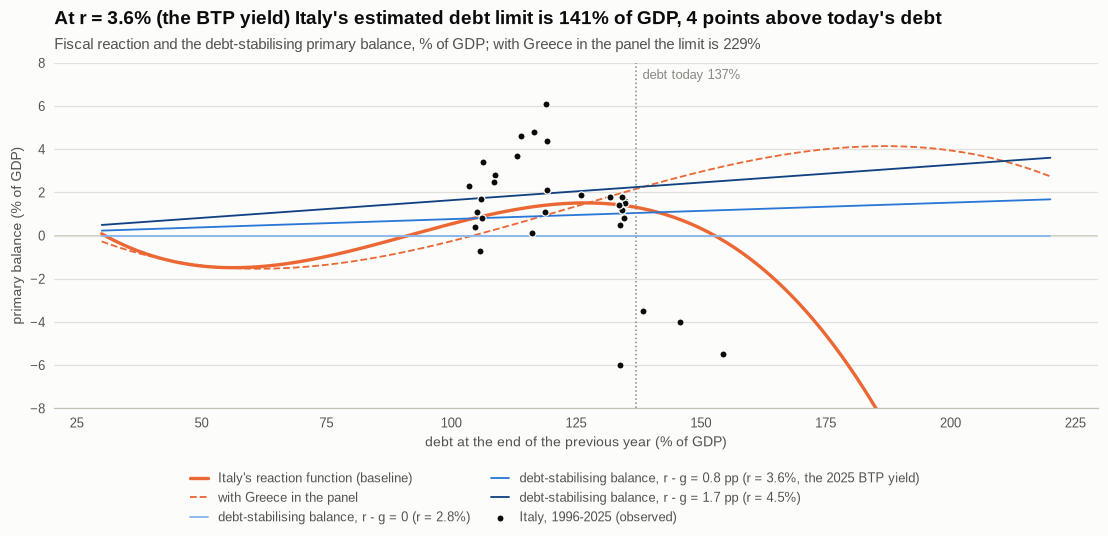

In [4]:
it = panel[panel["geo"] == "IT"].set_index("year")
d_now = float(it["debt"].dropna().iloc[-1])
grid = np.linspace(0.3, 2.2, 400)
limits = {}
for label, fit in (("baseline (without Greece)", base), ("with Greece", full)):
    for sc, r in R_SCENARIOS.items():
        limits[(label, sc)] = fs.debt_limit(lambda x, fit=fit: fs.reaction(fit, "IT", x), r, G_NOMINAL, 0.0, d_now)
lim = pd.Series(limits).unstack()
print(f"Italy's debt at the end of {it['debt'].dropna().index[-1]}: {100 * d_now:.1f}% of GDP; debt limits (% of GDP, "
      "NaN = no debt level is stabilised, inf = none within 300%):")
display((100 * lim).round(0))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(100 * grid, 100 * fs.reaction(base, "IT", grid), color=SERIES[1], lw=2.2, label="Italy's reaction function (baseline)")
ax.plot(100 * grid, 100 * fs.reaction(full, "IT", grid), color=SERIES[1], lw=1.2, ls="--", label="with Greece in the panel")
for (sc, r), c in zip(R_SCENARIOS.items(), ordinal_colors(len(R_SCENARIOS))):   # darker blue = higher r - g
    ax.plot(100 * grid, 100 * fs.required_balance(grid, r, G_NOMINAL), color=c, lw=1.2, label=f"debt-stabilising balance, {sc}")
ax.scatter(100 * it["debt_lag"], 100 * it["primary_balance"], s=22, color=NOTEBOOK["ink"], edgecolors=NOTEBOOK["surface"],
           linewidths=0.8, zorder=5, label="Italy, 1996-2025 (observed)")
ax.axvline(100 * d_now, color=MUTED, ls=":", lw=1)
ax.annotate(f"debt today {100 * d_now:.0f}%", (100 * d_now, 8), xytext=(4, -4), textcoords="offset points", va="top",
            fontsize=8.5, color=MUTED)
ax.axhline(0, color=NOTEBOOK["axis"], lw=1.0, zorder=0)
ax.set(xlabel="debt at the end of the previous year (% of GDP)", ylabel="primary balance (% of GDP)", ylim=(-8, 8))
sc_btp = next(sc for sc in R_SCENARIOS if "BTP" in sc)
lim_base, lim_el = lim.loc["baseline (without Greece)", sc_btp], lim.loc["with Greece", sc_btp]
r_btp = f"At r = {100 * R_SCENARIOS[sc_btp]:.1f}% (the BTP yield)"
if np.isfinite(lim_base) and np.isfinite(lim_el):
    headline(ax, f"{r_btp} Italy's estimated debt limit is {100 * lim_base:.0f}% of GDP, "
                 f"{100 * abs(lim_base - d_now):.0f} points {'above' if lim_base > d_now else 'below'} today's debt",
             f"Fiscal reaction and the debt-stabilising primary balance, % of GDP; with Greece in the panel the limit "
             f"is {100 * lim_el:.0f}%")
else:
    headline(ax, f"{r_btp} the baseline reaction function has no finite debt limit",
             "Fiscal reaction and the debt-stabilising primary balance, % of GDP")
fig.legend(loc="outside lower center", ncol=2)
fig.savefig(OUTPUT_DIR / "italy_debt_limit.png", dpi=150)

## 4. How uncertain is the debt limit?

The coefficients are drawn 5,000 times from their estimated normal distribution (Driscoll-Kraay covariance). Each draw
gives a debt limit; the table reports its distribution and the probability that the limit is already below current debt.

In [5]:
rows = {}
for label, fit in (("baseline (without Greece)", base), ("with Greece", full)):
    for sc, r in R_SCENARIOS.items():
        dr = fs.debt_limit_draws(fit, "IT", r, G_NOMINAL, 0.0, d_now, n_draws=N_DRAWS, seed=SEED)
        x = np.where(np.isinf(dr), 3.0, np.nan_to_num(dr, nan=0.0))   # inf -> 300% (grid end), NaN -> 0 (no limit)
        q = np.quantile(x, [0.05, 0.5, 0.95])
        rows[(label, sc)] = {"5%": 100 * q[0], "median": 100 * q[1], "95%": 100 * q[2],
                             "P(limit below current debt)": np.mean(x < d_now),
                             "P(no sustainable level)": np.mean(np.isnan(dr))}
display(pd.DataFrame(rows).T.round(2))

5%  \
baseline (without Greece) r - g = 0 (r = 2.8%)                          141.54   
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield) 133.22   
                          r - g = 1.7 pp (r = 4.5%)                       5.22   
with Greece               r - g = 0 (r = 2.8%)                          210.55   
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield) 198.21   
                          r - g = 1.7 pp (r = 4.5%)                      31.29   

                                                                         median  \
baseline (without Greece) r - g = 0 (r = 2.8%)                           152.71   
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield)  141.34   
                          r - g = 1.7 pp (r = 4.5%)                       28.74   
with Greece               r - g = 0 (r = 2.8%)                           241.17   
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield)  229.44   
                          r - g = 1.7 pp (r = 4.5%)                      210.76   

                                                                           95%  \
baseline (without Greece) r - g = 0 (r = 2.8%)                          218.75   
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield) 201.04   
                          r - g = 1.7 pp (r = 4.5%)                     149.29   
with Greece               r - g = 0 (r = 2.8%)                          300.00   
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield) 300.00   
                          r - g = 1.7 pp (r = 4.5%)                     299.62   

                                                                         P(limit below current debt)  \
baseline (without Greece) r - g = 0 (r = 2.8%)                                                  0.00   
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield)                         0.27   
                          r - g = 1.7 pp (r = 4.5%)                                             0.95   
with Greece               r - g = 0 (r = 2.8%)                                                  0.00   
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield)                         0.00   
                          r - g = 1.7 pp (r = 4.5%)                                             0.06   

                                                                         P(no sustainable level)  
baseline (without Greece) r - g = 0 (r = 2.8%)                                              0.00  
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield)                     0.00  
                          r - g = 1.7 pp (r = 4.5%)                                         0.03  
with Greece               r - g = 0 (r = 2.8%)                                              0.00  
                          r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield)                     0.00  
                          r - g = 1.7 pp (r = 4.5%)                                         0.00

## 5. Sovereign spreads and fundamentals

Spreads of 10-year yields over the Bund (percentage points) on lagged debt, the lagged primary balance and real growth, with
country and year effects (the year effects absorb the common factors: global risk aversion, ECB policy, Bund safe-haven flows).
The debt slope is allowed to change from 2009. The fitted value is the spread explained by fundamentals and the common year
effect; the residual is the part not explained by fundamentals.

,coefficient,s.e. (Driscoll-Kraay),t,coefficient with Greece,t with Greece
debt_lag,1.16,0.41,2.84,1.09,1.31
debt_lag x post,1.14,0.34,3.35,2.24,3.35
pb_lag,-9.78,3.31,-2.95,-6.20,-2.44
real_growth,-7.18,4.18,-1.72,-25.13,-1.99


observations 243, 1999-2025, within R2 0.64
post-2008 debt slope: 2.30 pp of spread per 100 pp of debt (s.e. 0.64, p = 0.0003)


year,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
actual,0.70,1.09,1.30,2.81,3.99,2.75,1.73,1.21,1.40,1.79,2.21,2.20,1.68,1.18,2.02,1.85,1.39,1.00
fundamental,0.69,1.46,1.50,2.69,3.13,1.86,1.38,1.27,1.42,1.55,1.55,1.60,1.64,1.41,1.94,1.90,1.79,1.38
residual,0.01,-0.37,-0.20,0.12,0.86,0.89,0.35,-0.06,-0.02,0.24,0.66,0.60,0.04,-0.23,0.08,-0.05,-0.40,-0.38


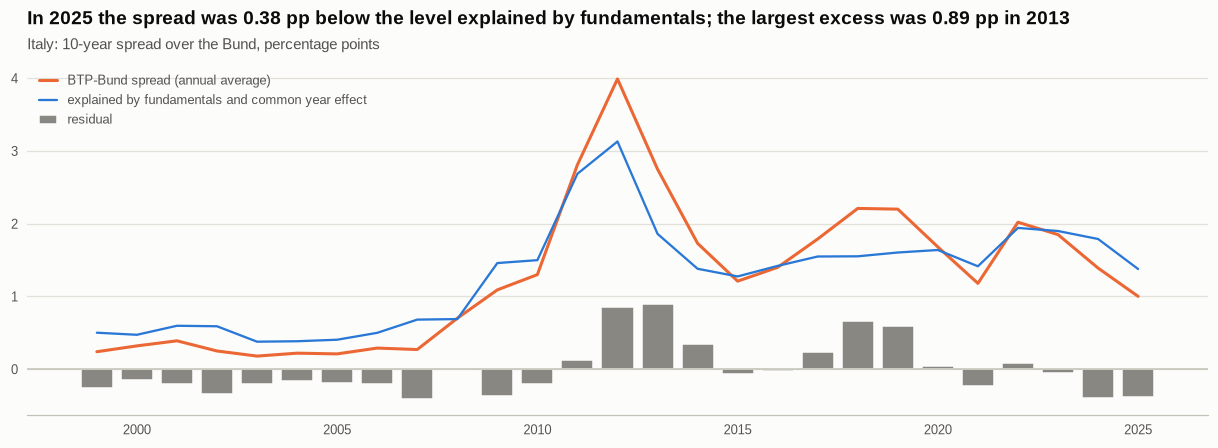

In [6]:
spreads = fs.spread_regression(panel, SPREAD_GEOS, 1999, BREAK_YEAR, time_effects=True, lags=DK_LAGS)
with_el = fs.spread_regression(panel, tuple(SPREAD_GEOS) + ("EL",), 1999, BREAK_YEAR, time_effects=True, lags=DK_LAGS)
tab = pd.DataFrame({"coefficient": spreads["coef"], "s.e. (Driscoll-Kraay)": spreads["se"], "t": spreads["t"],
                    "coefficient with Greece": with_el["coef"], "t with Greece": with_el["t"]})
display(tab.round(3))
post = fs.wald_test(spreads, ["debt_lag", "debt_lag x post"])
print(f"observations {spreads['n']}, {spreads['years'][0]}-{spreads['years'][1]}, within R2 {spreads['r2_within']:.2f}")
print(f"post-2008 debt slope: {post['estimate']:.2f} pp of spread per 100 pp of debt (s.e. {post['se']:.2f}, p = {post['p_value']:.4f})")
fund = fs.fundamental_spread(spreads, "IT")
display(fund.loc[2008:].round(2).T)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(fund.index, fund["actual"], color=SERIES[1], lw=2, label="BTP-Bund spread (annual average)")
ax.plot(fund.index, fund["fundamental"], color=SERIES[0], lw=1.5, label="explained by fundamentals and common year effect")
ax.bar(fund.index, fund["residual"], color=MUTED, label="residual")
ax.axhline(0, color=NOTEBOOK["axis"], lw=1.0)
res = fund["residual"].dropna()
headline(ax, f"In {res.index[-1]} the spread was {abs(res.iloc[-1]):.2f} pp {'below' if res.iloc[-1] < 0 else 'above'} "
             f"the level explained by fundamentals; the largest excess was {res.max():.2f} pp in {res.idxmax()}",
         "Italy: 10-year spread over the Bund, percentage points")
ax.legend(loc="upper left")
fig.savefig(OUTPUT_DIR / "btp_bund_fundamentals.png", dpi=150)

## 6. Debt limit with a debt-dependent interest rate

If the marginal interest rate rises with debt as spreads did after 2008, $r(d) = r_0 + \kappa\,(d - d_0)$ with $\kappa$ the
post-2008 spread slope, the debt-stabilising line bends upwards and the debt limit falls. The draws also include the
uncertainty on $\kappa$.

In [7]:
kappa, kappa_se = post["estimate"] / 100, post["se"] / 100
rows = {}
for sc, r in R_SCENARIOS.items():
    for label, k, kse in (("constant rate", 0.0, 0.0), (f"rate rising {100 * kappa:.1f} bp per pp of debt", kappa, kappa_se)):
        point = fs.debt_limit(lambda x: fs.reaction(base, "IT", x), r, G_NOMINAL, k, d_now)
        dr = fs.debt_limit_draws(base, "IT", r, G_NOMINAL, k, d_now, n_draws=N_DRAWS, seed=SEED, kappa_se=kse)
        x = np.where(np.isinf(dr), 3.0, np.nan_to_num(dr, nan=0.0))
        above = np.isfinite(point) and point >= d_now
        rows[(sc, label)] = {"debt limit (% of GDP)": f"{100 * point:.0f}" if above else "below current debt",
                             "fiscal space (pp of GDP)": f"{100 * (point - d_now):.1f}" if above else "none",
                             "P(limit below current debt)": f"{np.mean(x < d_now):.2f}"}
display(pd.DataFrame(rows).T)
need = fs.required_balance(d_now, 0.036, G_NOMINAL)
print(f"primary balance that stabilises debt at {100 * d_now:.0f}% with r = 3.6% and g = {100 * G_NOMINAL:.1f}%: "
      f"{100 * need:.2f}% of GDP (2025 outcome: {100 * it['primary_balance'].dropna().iloc[-1]:.2f}%)")

debt limit (% of GDP)  \
r - g = 0 (r = 2.8%)                          constant rate                                       153   
                                              rate rising 2.3 bp per pp of debt                   149   
r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield) constant rate                                       141   
                                              rate rising 2.3 bp per pp of debt                   140   
r - g = 1.7 pp (r = 4.5%)                     constant rate                        below current debt   
                                              rate rising 2.3 bp per pp of debt    below current debt   

                                                                                fiscal space (pp of GDP)  \
r - g = 0 (r = 2.8%)                          constant rate                                         15.7   
                                              rate rising 2.3 bp per pp of debt                     12.2   
r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield) constant rate                                          4.3   
                                              rate rising 2.3 bp per pp of debt                      2.9   
r - g = 1.7 pp (r = 4.5%)                     constant rate                                         none   
                                              rate rising 2.3 bp per pp of debt                     none   

                                                                                P(limit below current debt)  
r - g = 0 (r = 2.8%)                          constant rate                                            0.00  
                                              rate rising 2.3 bp per pp of debt                        0.00  
r - g = 0.8 pp (r = 3.6%, the 2025 BTP yield) constant rate                                            0.27  
                                              rate rising 2.3 bp per pp of debt                        0.27  
r - g = 1.7 pp (r = 4.5%)                     constant rate                                            0.95  
                                              rate rising 2.3 bp per pp of debt                        0.97

primary balance that stabilises debt at 137% with r = 3.6% and g = 2.8%: 1.05% of GDP (2025 outcome: 0.80%)


## 7. Conclusions

Results on Eurostat data up to 2025 (in synthetic mode the numbers differ).

**Facts (computed from the data).**

- Italy's debt was 137.1% of GDP at the end of 2025, with a primary surplus of 0.8% of GDP. Over 1995-2025 its average
  primary balance, 1.2% of GDP, was among the highest of the 13 countries (only Denmark, Belgium, Finland and Sweden did
  better).
- At a marginal rate of 3.6% (the 2025 BTP yield) and nominal growth of 2.8%, stabilising the debt at 137% requires a primary
  surplus of about 1.05% of GDP: the 2025 surplus is close to, but below, that level.
- The BTP-Bund spread averaged 1.0 percentage point in 2025, the lowest since 2010.

**Estimates (model-based, with their uncertainty).**

- On average across the panel the primary balance does not respond linearly to debt (0.006, s.e. 0.020). With year effects
  the cubic reproduces the fiscal-fatigue pattern of Ghosh et al. (2013). Governments strengthen the primary balance as debt
  rises from about 56% to 127% of GDP, and the response weakens beyond that. Italy's current debt is past the fatigue point.
  With errors clustered by country or on the 1996-2019 sample the cubic terms are not significant at 5%: the evidence of
  fatigue is suggestive, not conclusive.
- Italy's **debt limit** under the baseline is about 153% of GDP if $r = g$ and **141% at the current $r - g$ of 0.8 points**,
  only 4 points above current debt. The 90% interval is 133-201%, and the limit is already below current debt in 27% of the
  draws. If $r - g$ rises to 1.7 points, no debt level above the current one is stabilised in 95% of the draws.
- **The debt limit is highly sensitive to the specification.** With Greece in the panel it rises to 229%, because Greece's
  programme-era surpluses at very high debt make the estimated response rise up to 187% of GDP. This sensitivity is a result
  in itself: debt limits are not precise numbers.
- **Markets price debt much more since 2008.** The spread sensitivity doubled from 1.2 to 2.3 percentage points per 100 points
  of debt (s.e. 0.64); each point of GDP of primary surplus lowers the spread by about 0.1 points. For Italy the spread
  exceeded fundamentals by 0.6-0.9 points in 2012-2013 (sovereign debt crisis) and in 2018-2019 (budget dispute with the
  European Commission), and was about 0.4 points below them in 2024-2025. Candidate explanations for the gap, not tested
  here, include the ECB's Transmission Protection Instrument, the Next Generation EU funds and rating upgrades.
- A debt-dependent interest rate lowers the limit only slightly at current rates (to 140%): the larger effect comes from the
  level of $r - g$, not from the slope.

**Judgement (for discussion).** On historical behaviour Italy has little fiscal space: a few points of GDP at today's rates
and none if the interest-growth differential widens by about one point. Two things protect debt stability. The first is a
primary surplus of at least 1-1.5% of GDP kept through the cycle. The second is a lower $r - g$, through higher potential
growth and a credible fiscal path that keeps spreads anchored. Today's spreads below fundamentals are a window to use, not a
guarantee.

**Limitations.** Annual data and 12-13 countries over 30 years; the output gap is an HP filter, not the Commission's
production-function estimate; year effects absorb common shocks but not country-specific political events; the reaction
function describes average past behaviour, and fiscal rules (the 2024 EU framework) can change it; Maastricht yields are
secondary-market averages; spreads also reflect liquidity and ECB purchases, which are not modelled separately.